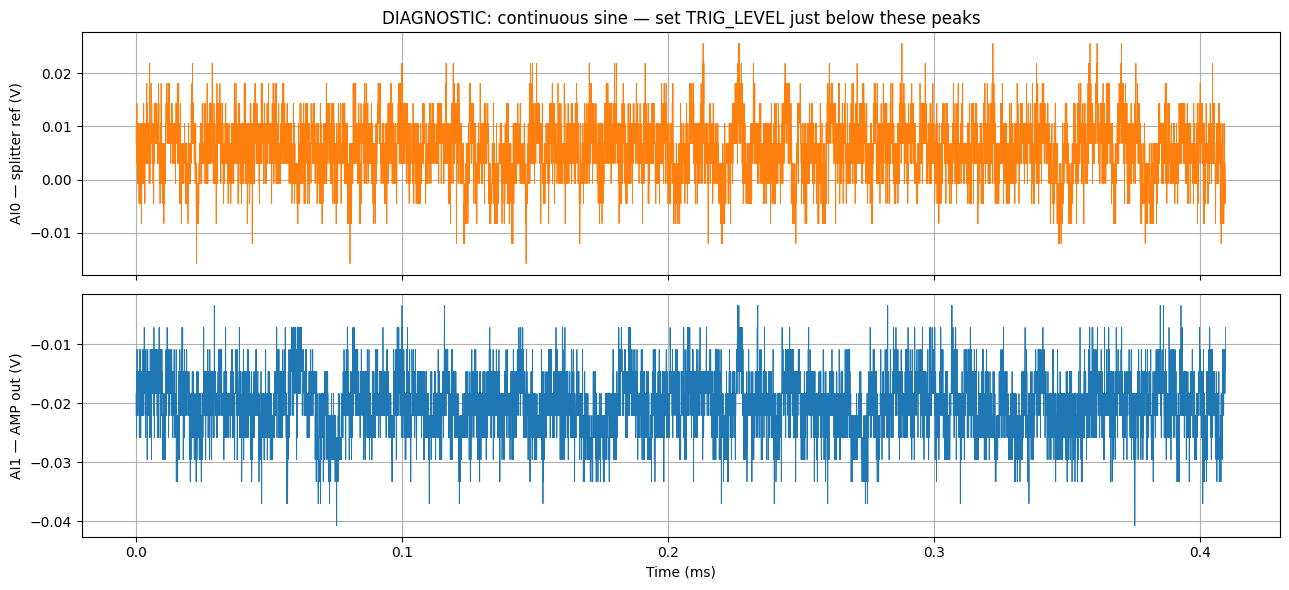

AI0 peak : 0.0256 V  (splitter-attenuated AWG)
AI1 peak : 0.0408 V  (amplifier output)
AI0 noise floor (10th pct): 0.0007 V

>>> Set TRIG_LEVEL = 0.013 V  in the experiment below <<<


In [88]:
import time
import numpy as np
import matplotlib.pyplot as plt
import dwfpy as dwf

# ══════════════════════════════════════════════════════════════════════════════
#  STEP 1 — DIAGNOSTIC: fire AWG continuously, capture with AUTO trigger
#  Goal: see actual signal levels on AI0 and AI1 to set threshold correctly
#  W1 → splitter → AI0  +  RF AMP out → AI1
# ══════════════════════════════════════════════════════════════════════════════

SCOPE_FS     = 20e6
SCOPE_BUFFER = 50_000
WAVE_TS      = 1.0 / SCOPE_FS
AWG_AMP      = 0.5
AWG_FREQ     = 2e6

with dwf.AnalogDiscovery2() as dev:
    scope   = dev.analog_input
    wavegen = dev.analog_output
    scope.reset(); wavegen[0].reset()

    # AUTO trigger — captures immediately regardless of level, no threshold needed
    scope.setup_edge_trigger(mode="auto", channel=0, slope="rising", level=0.0)
    scope.single(sample_rate=SCOPE_FS, buffer_size=SCOPE_BUFFER,
                 configure=True, start=False)

    # Fire AWG continuously so we're guaranteed to catch it
    awg     = wavegen[0]
    carrier = awg.nodes[dwf.AnalogOutputNode.CARRIER]
    carrier.enabled   = True
    carrier.function  = dwf.Function.SINE
    carrier.frequency = AWG_FREQ
    carrier.amplitude = AWG_AMP
    carrier.offset    = 0.0
    awg.repeat_count  = 0          # continuous — not a burst

    scope.configure(start=True)
    time.sleep(0.05)
    awg.configure(start=True)
    time.sleep(0.1)                # let it run so scope definitely catches it

    t0 = time.time()
    while scope.read_status(read_data=True) != dwf.Status.DONE:
        if time.time() - t0 > 3.0:
            raise TimeoutError("AUTO trigger failed — hardware issue.")
        time.sleep(0.001)

    ch0 = np.array(scope[0].get_data(), dtype=np.float32)
    ch1 = np.array(scope[1].get_data(), dtype=np.float32)
    wavegen[0].reset()             # stop AWG

t = np.arange(len(ch0)) * WAVE_TS

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(t * 1e3, ch0, lw=0.6, color="tab:orange")
axes[0].set_ylabel("AI0 — splitter ref (V)"); axes[0].grid(True)
axes[0].set_title("DIAGNOSTIC: continuous sine — set TRIG_LEVEL just below these peaks")

axes[1].plot(t * 1e3, ch1, lw=0.6, color="tab:blue")
axes[1].set_ylabel("AI1 — AMP out (V)"); axes[1].set_xlabel("Time (ms)"); axes[1].grid(True)
plt.tight_layout(); plt.show()

ai0_peak = np.max(np.abs(ch0))
ai1_peak = np.max(np.abs(ch1))
noise_floor_ai0 = np.percentile(np.abs(ch0), 10)

print(f"AI0 peak : {ai0_peak:.4f} V  (splitter-attenuated AWG)")
print(f"AI1 peak : {ai1_peak:.4f} V  (amplifier output)")
print(f"AI0 noise floor (10th pct): {noise_floor_ai0:.4f} V")
print()
# Suggest threshold: halfway between noise floor and signal peak
suggested_trig = round((noise_floor_ai0 + ai0_peak) / 2, 3)
print(f">>> Set TRIG_LEVEL = {suggested_trig:.3f} V  in the experiment below <<<")

C:\Users\abdul\AppData\Local\Temp\ipykernel_17764\2003146763.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].set_title("RX spectrum"); axes[2].legend(); axes[2].grid(True)


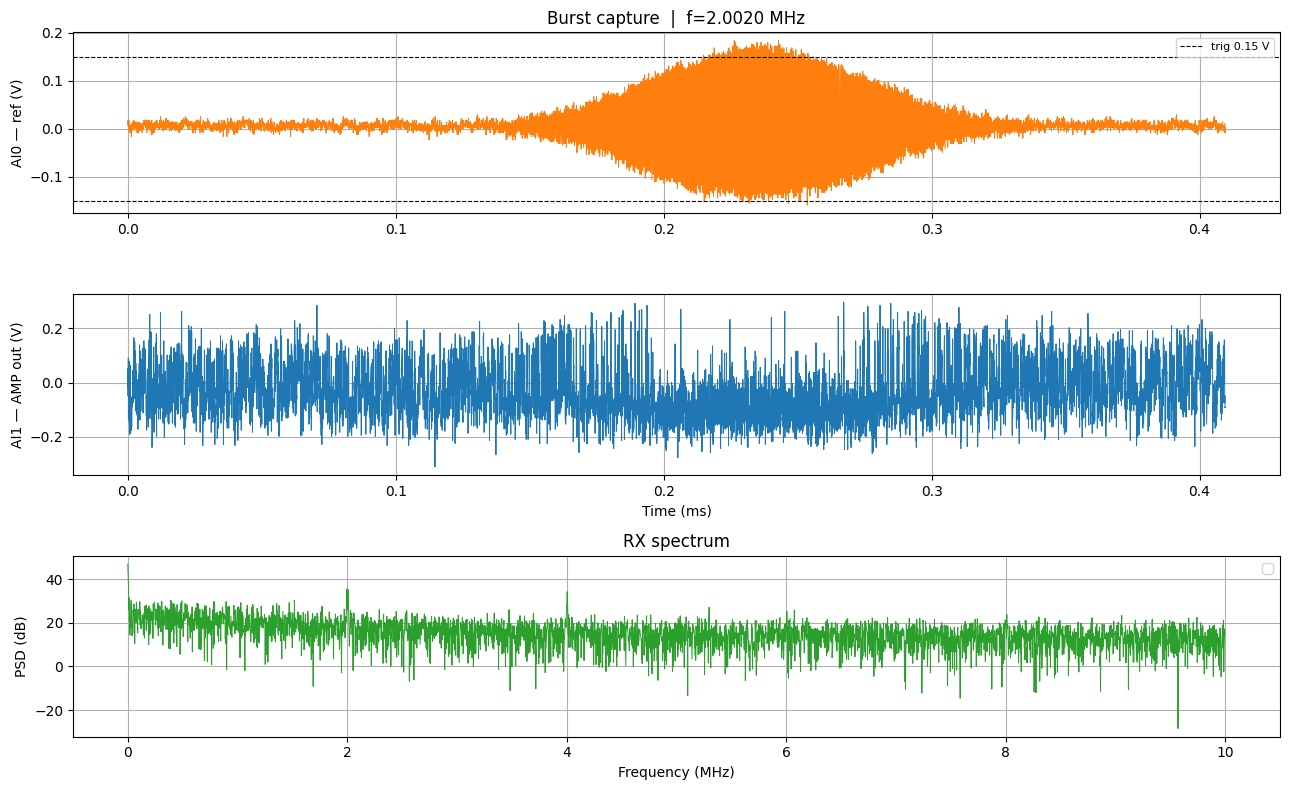

peak=0.3101 V  SNR=1.4 dB  decay=0.882


In [91]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2 — EXPERIMENT: single burst capture with correct threshold
# ══════════════════════════════════════════════════════════════════════════════

SCOPE_FS        = 20e6
SCOPE_BUFFER    = 50_000
WAVE_NS         = 4096
WAVE_TS         = 1.0 / SCOPE_FS
BUFFER_DURATION = WAVE_NS * WAVE_TS

TRIG_LEVEL = 0.15    # ← paste suggested value from diagnostic above
CH_TRIG    = 0       # AI0 — splitter ref
CH_RX      = 1       # AI1 — amp output
CH_AWG     = 0       # W1

def make_burst(f0_hz, width_s, amp):
    n_cycles = round(f0_hz * BUFFER_DURATION)
    f_actual = n_cycles / BUFFER_DURATION
    t        = (np.arange(WAVE_NS) - WAVE_NS / 2) * WAVE_TS
    raw      = np.exp(-(t**2) / (2 * width_s**2)) * np.sin(2 * np.pi * f_actual * t)
    burst    = amp * raw / (np.max(np.abs(raw)) + 1e-12)
    return burst, f_actual

def capture(f0_hz, amp, width_s, timeout_s=3.0):
    burst, f_actual = make_burst(f0_hz=f0_hz, width_s=width_s, amp=amp)

    assert np.max(np.abs(burst)) > TRIG_LEVEL, \
        f"Burst peak {np.max(np.abs(burst)):.3f} V ≤ TRIG_LEVEL {TRIG_LEVEL} V — lower TRIG_LEVEL or raise amp"

    with dwf.AnalogDiscovery2() as dev:
        scope   = dev.analog_input
        wavegen = dev.analog_output
        scope.reset(); wavegen[0].reset()

        scope.setup_edge_trigger(mode="normal", channel=CH_TRIG,
                                 slope="rising", level=TRIG_LEVEL)
        scope.single(sample_rate=SCOPE_FS, buffer_size=SCOPE_BUFFER,
                     configure=True, start=False)

        awg     = wavegen[CH_AWG]
        carrier = awg.nodes[dwf.AnalogOutputNode.CARRIER]
        carrier.enabled   = True
        carrier.function  = dwf.Function.CUSTOM
        carrier.set_data_samples(burst.tolist())
        carrier.frequency = 1.0 / BUFFER_DURATION
        carrier.amplitude = 1.0
        carrier.offset    = 0.0
        awg.idle          = dwf.AnalogOutputIdle.INITIAL
        awg.wait_length   = 0.0
        awg.run_length    = BUFFER_DURATION
        awg.repeat_count  = 1

        scope.configure(start=True)
        time.sleep(0.1)            # scope fully armed — longer than before
        awg.configure(start=True)

        t0 = time.time()
        while scope.read_status(read_data=True) != dwf.Status.DONE:
            if time.time() - t0 > timeout_s:
                raise TimeoutError(
                    f"No trigger on AI0. "
                    f"Burst peak={np.max(np.abs(burst)):.3f} V, "
                    f"TRIG_LEVEL={TRIG_LEVEL} V. "
                    f"Re-run diagnostic to check actual AI0 level."
                )
            time.sleep(0.001)

        ch0 = np.array(scope[CH_TRIG].get_data(), dtype=np.float32)
        ch1 = np.array(scope[CH_RX].get_data(),   dtype=np.float32)

    t = np.arange(len(ch0)) * WAVE_TS
    return t, ch0, ch1, f_actual

def measure(t, ch1, f0_hz):
    noise_mask = t < (t[-1] * 0.10)
    sig_mask   = (t >= BUFFER_DURATION * 0.3) & (t <= BUFFER_DURATION * 1.8)
    tail_mask  = t > (t[-1] * 0.75)

    y_noise = ch1[noise_mask] if noise_mask.any() else ch1[:50]
    y_sig   = ch1[sig_mask]   if sig_mask.any()   else ch1
    y_tail  = ch1[tail_mask]  if tail_mask.any()  else ch1[-50:]

    rms_noise   = float(np.sqrt(np.mean(y_noise**2))) + 1e-12
    rms_sig     = float(np.sqrt(np.mean(y_sig**2)))
    snr_db      = 20 * np.log10(rms_sig / rms_noise)
    peak_v      = float(np.max(np.abs(ch1)))
    decay_ratio = float(np.sqrt(np.mean(y_tail**2))) / (rms_sig + 1e-12)

    f_b       = np.fft.rfftfreq(len(y_sig), d=WAVE_TS)
    band_mask = (f_b >= f0_hz * 0.8) & (f_b <= f0_hz * 1.2)
    bandpower = float(np.sum(np.abs(np.fft.rfft(y_sig)[band_mask])**2) / len(y_sig))

    return dict(peak_v=peak_v, snr_db=snr_db,
                bandpower=bandpower, decay_ratio=decay_ratio)

def sweep(param, values, f0_hz=2e6, amp=0.5, width_s=40e-6, metric="snr_db"):
    assert param in ("f0_hz", "amp", "width_s")
    results, captures = [], []
    for v in values:
        kwargs = dict(f0_hz=f0_hz, amp=amp, width_s=width_s)
        kwargs[param] = v
        t, ch0, ch1, _ = capture(**kwargs)
        m = measure(t, ch1, kwargs["f0_hz"])
        results.append(m[metric])
        captures.append((t, ch0, ch1))
        print(f"  {param}={v:.4g}  →  {metric}={m[metric]:.3f}")
    return np.array(values), np.array(results), captures

# ── Single shot ────────────────────────────────────────────────────────────────
t, ch0, ch1, f_actual = capture(f0_hz=2e6, amp=0.2, width_s=40e-6)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=False)
axes[0].plot(t * 1e3, ch0, lw=0.7, color="tab:orange")
axes[0].axhline( TRIG_LEVEL, ls="--", color="k", lw=0.8, label=f"trig {TRIG_LEVEL} V")
axes[0].axhline(-TRIG_LEVEL, ls="--", color="k", lw=0.8)
axes[0].set_ylabel("AI0 — ref (V)"); axes[0].legend(fontsize=8); axes[0].grid(True)
axes[0].set_title(f"Burst capture  |  f={f_actual/1e6:.4f} MHz")

axes[1].plot(t * 1e3, ch1, lw=0.7, color="tab:blue")
axes[1].set_ylabel("AI1 — AMP out (V)"); axes[1].set_xlabel("Time (ms)"); axes[1].grid(True)

f_spec = np.fft.rfftfreq(len(ch1), d=WAVE_TS)
psd    = np.abs(np.fft.rfft(ch1))**2
axes[2].plot(f_spec / 1e6, 10 * np.log10(psd + 1e-30), lw=0.7, color="tab:green")
# axes[2].axvline(f_actual / 1e6, ls="--", color="k", lw=1, label=f"{f_actual/1e6:.4f} MHz")
axes[2].set_xlabel("Frequency (MHz)"); axes[2].set_ylabel("PSD (dB)")
axes[2].set_title("RX spectrum"); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

m = measure(t, ch1, f0_hz=2e6)
print(f"peak={m['peak_v']:.4f} V  SNR={m['snr_db']:.1f} dB  decay={m['decay_ratio']:.3f}")

Coarse sweep ...
  1.000 MHz  →  bandpower=6.209  SNR=1.5 dB
  1.138 MHz  →  bandpower=5.986  SNR=1.1 dB
  1.276 MHz  →  bandpower=4.643  SNR=1.6 dB
  1.414 MHz  →  bandpower=5.15  SNR=1.5 dB
  1.552 MHz  →  bandpower=4.117  SNR=1.3 dB
  1.690 MHz  →  bandpower=4.928  SNR=1.1 dB
  1.828 MHz  →  bandpower=4.846  SNR=1.3 dB
  1.966 MHz  →  bandpower=5.331  SNR=1.7 dB
  2.103 MHz  →  bandpower=4.879  SNR=1.5 dB
  2.241 MHz  →  bandpower=4.63  SNR=1.4 dB
  2.379 MHz  →  bandpower=5.071  SNR=1.3 dB
  2.517 MHz  →  bandpower=4.491  SNR=1.2 dB
  2.655 MHz  →  bandpower=4.651  SNR=1.4 dB
  2.793 MHz  →  bandpower=5.29  SNR=1.3 dB
  2.931 MHz  →  bandpower=5.411  SNR=0.9 dB
  3.069 MHz  →  bandpower=5.417  SNR=1.7 dB
  3.207 MHz  →  bandpower=5.238  SNR=1.3 dB
  3.345 MHz  →  bandpower=5.894  SNR=1.5 dB
  3.483 MHz  →  bandpower=5.97  SNR=1.5 dB
  3.621 MHz  →  bandpower=5.755  SNR=1.4 dB
  3.759 MHz  →  bandpower=6.215  SNR=1.0 dB
  3.897 MHz  →  bandpower=6.569  SNR=1.3 dB
  4.034 MHz  →  ban

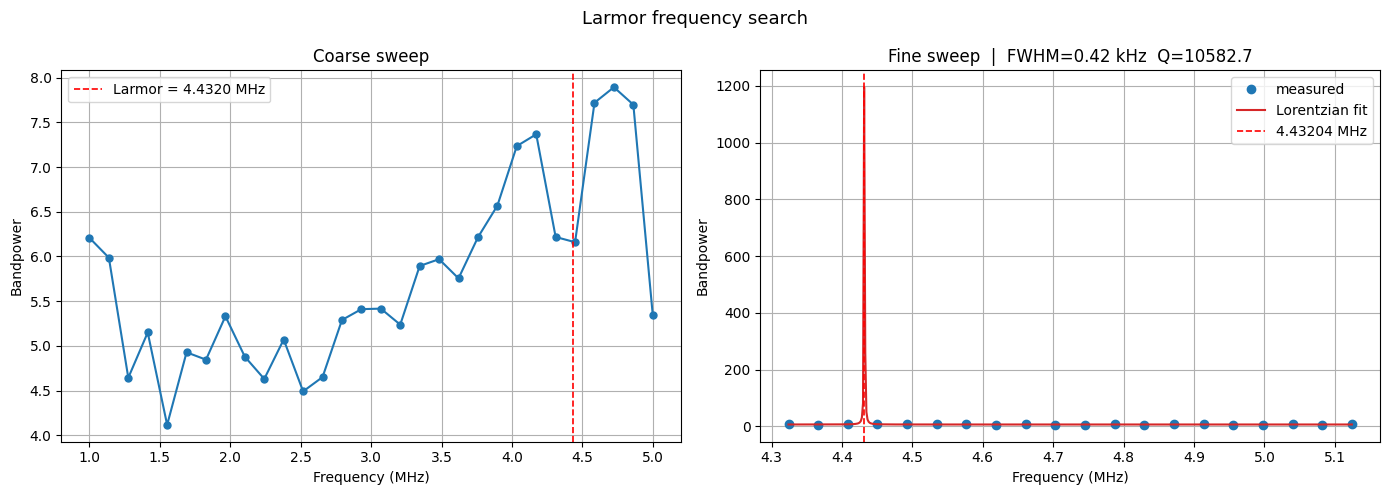


Capturing at Larmor frequency 4.43204 MHz ...


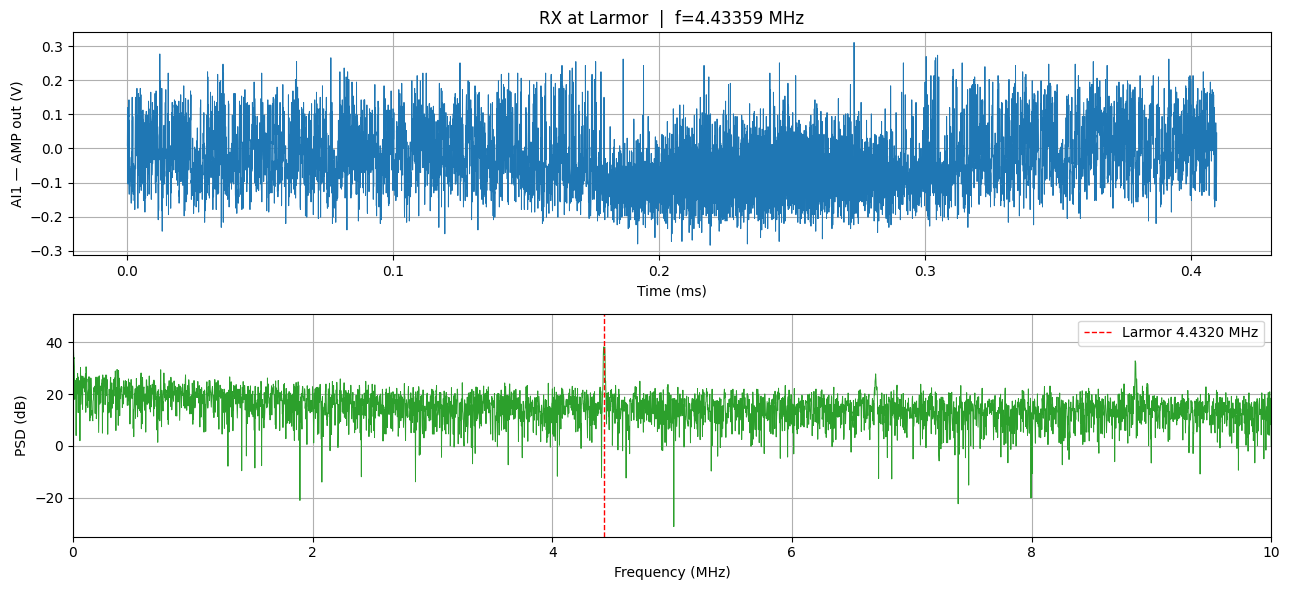

In [94]:
# ══════════════════════════════════════════════════════════════════════════════
#  LARMOR FREQUENCY FINDER
#  Sweeps carrier frequency, measures RX bandpower at each step,
#  fits a Lorentzian to find the resonance peak precisely.
#  Run AFTER the diagnostic cell — paste TRIG_LEVEL from there.
# ══════════════════════════════════════════════════════════════════════════════

# ── Sweep range — edit these ───────────────────────────────────────────────────
F_START  = 1.0e6    # Hz — start of sweep
F_STOP   = 5.0e6    # Hz — end of sweep
F_STEPS  = 30       # coarse first, refine after peak found
AWG_AMP  = 0.3      # V
WIDTH_S  = 40e-6    # Gaussian sigma — wide pulse = narrow bandwidth, good for frequency resolution

freqs_coarse = np.linspace(F_START, F_STOP, F_STEPS)

# ── Lorentzian fit for sub-bin frequency resolution ───────────────────────────
def lorentzian(f, f0, gamma, A, offset):
    return offset + A * (gamma/2)**2 / ((f - f0)**2 + (gamma/2)**2)

def fit_lorentzian(f_vals, y_vals):
    from scipy.optimize import curve_fit
    i0     = np.argmax(y_vals)
    p0     = [f_vals[i0], (F_STOP - F_START) / 5, y_vals[i0], np.min(y_vals)]
    bounds = ([F_START, 0, 0, -np.inf], [F_STOP, F_STOP - F_START, np.inf, np.inf])
    try:
        popt, _ = curve_fit(lorentzian, f_vals, y_vals, p0=p0, bounds=bounds, maxfev=10000)
        return popt   # f0, gamma, A, offset
    except Exception as e:
        print(f"Fit failed: {e}")
        return None

# ── Run coarse sweep ───────────────────────────────────────────────────────────
print("Coarse sweep ...")
bp_coarse = []
for f in freqs_coarse:
    t, ch0, ch1, f_actual = capture(f0_hz=f, amp=AWG_AMP, width_s=WIDTH_S)
    m = measure(t, ch1, f0_hz=f)
    bp_coarse.append(m["bandpower"])
    print(f"  {f/1e6:.3f} MHz  →  bandpower={m['bandpower']:.4g}  SNR={m['snr_db']:.1f} dB")

bp_coarse = np.array(bp_coarse)

# ── Zoom in around coarse peak for fine sweep ─────────────────────────────────
f_coarse_peak = freqs_coarse[np.argmax(bp_coarse)]
zoom_span     = (F_STOP - F_START) / F_STEPS * 3   # ± 3 coarse steps around peak
freqs_fine    = np.linspace(f_coarse_peak - zoom_span,
                            f_coarse_peak + zoom_span, 20)

print(f"\nFine sweep around {f_coarse_peak/1e6:.3f} MHz ...")
bp_fine = []
for f in freqs_fine:
    t, ch0, ch1, f_actual = capture(f0_hz=f, amp=AWG_AMP, width_s=WIDTH_S)
    m = measure(t, ch1, f0_hz=f)
    bp_fine.append(m["bandpower"])
    print(f"  {f/1e6:.4f} MHz  →  bandpower={m['bandpower']:.4g}")

bp_fine = np.array(bp_fine)

# ── Lorentzian fit on fine sweep ───────────────────────────────────────────────
popt = fit_lorentzian(freqs_fine, bp_fine)
f_larmor   = popt[0] if popt is not None else freqs_fine[np.argmax(bp_fine)]
linewidth  = popt[1] if popt is not None else np.nan
Q_factor   = f_larmor / linewidth if not np.isnan(linewidth) else np.nan

print(f"\n{'═'*50}")
print(f"  Larmor frequency : {f_larmor/1e6:.5f} MHz")
print(f"  Linewidth (FWHM) : {linewidth/1e3:.2f} kHz")
print(f"  Q factor         : {Q_factor:.1f}")
print(f"{'═'*50}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full coarse sweep
axes[0].plot(freqs_coarse / 1e6, bp_coarse, "o-", color="tab:blue", ms=5)
axes[0].axvline(f_larmor / 1e6, ls="--", color="r", lw=1.2,
                label=f"Larmor = {f_larmor/1e6:.4f} MHz")
axes[0].set_xlabel("Frequency (MHz)"); axes[0].set_ylabel("Bandpower")
axes[0].set_title("Coarse sweep"); axes[0].legend(); axes[0].grid(True)

# Right: fine sweep + Lorentzian fit
axes[1].plot(freqs_fine / 1e6, bp_fine, "o", color="tab:blue", ms=6, label="measured")
if popt is not None:
    f_fit = np.linspace(freqs_fine[0], freqs_fine[-1], 500)
    axes[1].plot(f_fit / 1e6, lorentzian(f_fit, *popt),
                 "-", color="tab:red", lw=1.5, label="Lorentzian fit")
axes[1].axvline(f_larmor / 1e6, ls="--", color="r", lw=1.2,
                label=f"{f_larmor/1e6:.5f} MHz")
axes[1].set_xlabel("Frequency (MHz)"); axes[1].set_ylabel("Bandpower")
axes[1].set_title(f"Fine sweep  |  FWHM={linewidth/1e3:.2f} kHz  Q={Q_factor:.1f}")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Larmor frequency search", fontsize=13)
plt.tight_layout(); plt.show()

# ── Capture one waveform exactly at Larmor frequency for inspection ────────────
print(f"\nCapturing at Larmor frequency {f_larmor/1e6:.5f} MHz ...")
t, ch0, ch1, f_actual = capture(f0_hz=f_larmor, amp=AWG_AMP, width_s=WIDTH_S)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
axes[0].plot(t * 1e3, ch1, lw=0.7, color="tab:blue")
axes[0].set_ylabel("AI1 — AMP out (V)"); axes[0].set_xlabel("Time (ms)")
axes[0].set_title(f"RX at Larmor  |  f={f_actual/1e6:.5f} MHz"); axes[0].grid(True)

f_spec = np.fft.rfftfreq(len(ch1), d=WAVE_TS)
psd    = np.abs(np.fft.rfft(ch1))**2
axes[1].plot(f_spec / 1e6, 10 * np.log10(psd + 1e-30), lw=0.7, color="tab:green")
axes[1].axvline(f_larmor / 1e6, ls="--", color="r", lw=1,
                label=f"Larmor {f_larmor/1e6:.4f} MHz")
axes[1].set_xlim(0, 10); axes[1].set_xlabel("Frequency (MHz)")
axes[1].set_ylabel("PSD (dB)"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()